In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import gc

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

import torch
import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

"""FINAL WARNING: UserWarning silenced!"""
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Load in muscle dataset

Dataset (0116c625-ea28-4b87-836c-201b9f674bf8.h5ad) was downloaded from CellxGene, called 'Skeletal_muscle' from 'Automatic cell-type harmonization and integration across Human Cell Atlas datasets'.

human_limb_scRNAseq.h5ad (315d639c-ab99-4bbf-85ee-82263665614d.h5ad), also downloaded from CellxGene. From [A human embryonic limb cell atlas resolved in space and time (Nature 2023)](https://www.nature.com/articles/s41586-023-06806-x)

In [2]:
%%time

# fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/0116c625-ea28-4b87-836c-201b9f674bf8.h5ad"
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/human_limb_scRNAseq.h5ad"

adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()

adata

Memory usage: current 7.78 GB, difference +7.78 GB
CPU times: user 25.2 s, sys: 4.97 s, total: 30.2 s
Wall time: 30.8 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 125955 × 26252
    obs: 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden', 'S_score', 'G2M_score', 'phase', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', 

In [3]:
print("Available layers:", list(adata.layers.keys()))
print("Available .uns keys:", list(adata.uns.keys()))
print("adata.raw is None?", adata.raw is None)

Available layers: []
Available .uns keys: ['adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', 'paga', 'pca', 'phase_colors', 'rank_genes_groups', 'region_colors', 'schema_reference', 'schema_version', 'title', 'umap']
adata.raw is None? False


In [5]:
total_cells = adata.n_obs

# Randomly sample 100 unique indices
sampled_indices = np.random.choice(total_cells, size=1000, replace=False)

tdata = adata[sampled_indices, :].copy()
tdata

AnnData object with n_obs × n_vars = 1000 × 26252
    obs: 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden', 'S_score', 'G2M_score', 'phase', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', 'p

In [6]:
X = tdata.X.toarray() if hasattr(tdata.X, "toarray") else tdata.X
print(np.min(X), np.max(X), np.mean(X))

0.0 8.328481 0.106412105


In [7]:
X_raw = tdata.raw.X
X_raw = X_raw.toarray() if hasattr(X_raw, "toarray") else X_raw

print(X_raw.min(), X_raw.max(), X_raw.mean())
print("Data type:", X_raw.dtype)

0.0 6207.0 0.28753132
Data type: float32


In [3]:
adata.var.head()

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
gene_ids,,,,,,
ENSG00000243485,False,MIR1302-2HG,NCBITaxon:9606,gene,623,lncRNA
ENSG00000238009,False,ENSG00000238009,NCBITaxon:9606,gene,629,lncRNA
ENSG00000239945,False,ENSG00000239945,NCBITaxon:9606,gene,1319,lncRNA
ENSG00000236601,False,ENSG00000236601,NCBITaxon:9606,gene,607,lncRNA
ENSG00000235146,False,ENSG00000235146,NCBITaxon:9606,gene,504,lncRNA


In [5]:
adata.obs.head()

,percent_mito,n_counts,n_genes,doublet_scores,bh_pval,region,adj_stage,adj_sample,leiden,S_score,...,tissue_type,tissue_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCTGCACATTTCT-5386STDY7537944,0.011364,2992.0,1152,0.286585,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,-0.117172,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,g!nA+E@sA(
AAACCTGCAGGGATTG-5386STDY7537944,0.006805,2939.0,1187,0.194631,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,-0.104853,...,tissue,UBERON:0002103,osteoblast,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,L-jN6<dDh*
AAACCTGCATCGGGTC-5386STDY7537944,0.011667,6857.0,2329,0.098748,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,0.033006,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,5P?|%v029%
AAACCTGCATGGGACA-5386STDY7537944,0.009933,10974.0,2967,0.185345,0.872782,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,12,0.106430,...,tissue,UBERON:0002103,mesenchymal cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,hhcuqnDpD{
AAACCTGGTGATGCCC-5386STDY7537944,0.015003,6532.0,2083,0.130000,0.927508,WholeLimb,Pcw5.1,Pcw5.1_WholeLimb_LowerLimb,26,-0.120746,...,tissue,UBERON:0002103,vein endothelial cell,10x 3' v2,normal,female,hindlimb,unknown,Carnegie stage 15,vj@>rw_0Y}


In [6]:
adata.obs[['celltype', 'cell_type', 'tissue']].head()

,celltype,cell_type,tissue
AAACCTGCACATTTCT-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGCAGGGATTG-5386STDY7537944,OCP,osteoblast,hindlimb
AAACCTGCATCGGGTC-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGCATGGGACA-5386STDY7537944,Mes1,mesenchymal cell,hindlimb
AAACCTGGTGATGCCC-5386STDY7537944,VenousEndo,vein endothelial cell,hindlimb


In [7]:
adata.obs['cell_type'].value_counts()

cell_type
mesenchymal cell                        49216
fibroblast of dermis                    14105
chondrocyte                             12599
skeletal muscle myoblast                10584
muscle fibroblast                        7010
osteoblast                               5804
fibroblast                               4650
chondroblast                             3356
primitive red blood cell                 1963
muscle cell                              1947
tendon cell                              1655
basal cell                               1343
vein endothelial cell                    1307
connective tissue cell                   1247
smooth muscle cell                       1208
myoblast                                 1157
Schwann cell                             1075
pericyte                                 1026
Schwann cell precursor                    960
peridermal cell                           817
macrophage                                588
articular chondrocyte   

In [4]:
# cell_types = [
#     'fast muscle cell', 
#     'slow muscle cell', 
#     'skeletal muscle satellite stem cell', 
#     'cell of skeletal muscle', 
#     'fibroblast',
# ]

cell_types = [
    'fibroblast of dermis',
    'fibroblast',
    'muscle fibroblast',
    'skeletal muscle myoblast',
    'myoblast',
    'muscle cell',
]

adata = adata[adata.obs['cell_type'].isin(cell_types)].copy()

adata

AnnData object with n_obs × n_vars = 39453 × 26252
    obs: 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden', 'S_score', 'G2M_score', 'phase', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'adj_stage_colors', 'celltype_colors', 'celltype_sizes', 'citation', 'default_embedding', 'leiden', 'leiden_sizes', 'markers_celltype', 'markers_new_celltype', 'neighbors', 'new_celltype_sizes', 'organism', 'organism_ontology_term_id', '

In [3]:
adata.var[adata.var['feature_name'] == 'MYOD1']

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
gene_ids,,,,,,
ENSG00000129152,False,MYOD1,NCBITaxon:9606,gene,1803,protein_coding


In [5]:
gene = 'ENSG00000129152'
gene_idx = adata.var_names.get_loc(gene)

# tmp = adata[:, gene].copy()

# tmp = adata.copy()

# tmp.X = tmp.layers['raw_counts'].copy()

tmp_expr = adata.X[:, gene_idx].copy()

if hasattr(tmp_expr, 'toarray'):
    tmp_expr = tmp_expr.toarray().flatten()
else:
    tmp_expr = np.asarray(tmp_expr).flatten()


tmp_df = pd.DataFrame({'expression': tmp_expr, 'group': adata.obs['cell_type'].values})

# tmp_df.head()
tmp_df.groupby('group')['expression'].describe()

/tmp/ipykernel_314248/94971531.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp_df.groupby('group')['expression'].describe()


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
myoblast,1157.0,1.260497,0.748595,0.0,0.778023,1.368021,1.783827,3.564034
fibroblast,4650.0,0.010372,0.115627,0.0,0.000000,0.000000,0.000000,2.271677
muscle cell,1947.0,1.062512,0.935107,0.0,0.000000,1.160454,1.870925,3.538277
skeletal muscle myoblast,10584.0,0.359539,0.560337,0.0,0.000000,0.000000,0.715712,3.282452
fibroblast of dermis,14105.0,0.007499,0.087900,0.0,0.000000,0.000000,0.000000,2.594626
muscle fibroblast,7010.0,0.008065,0.090787,0.0,0.000000,0.000000,0.000000,1.761575


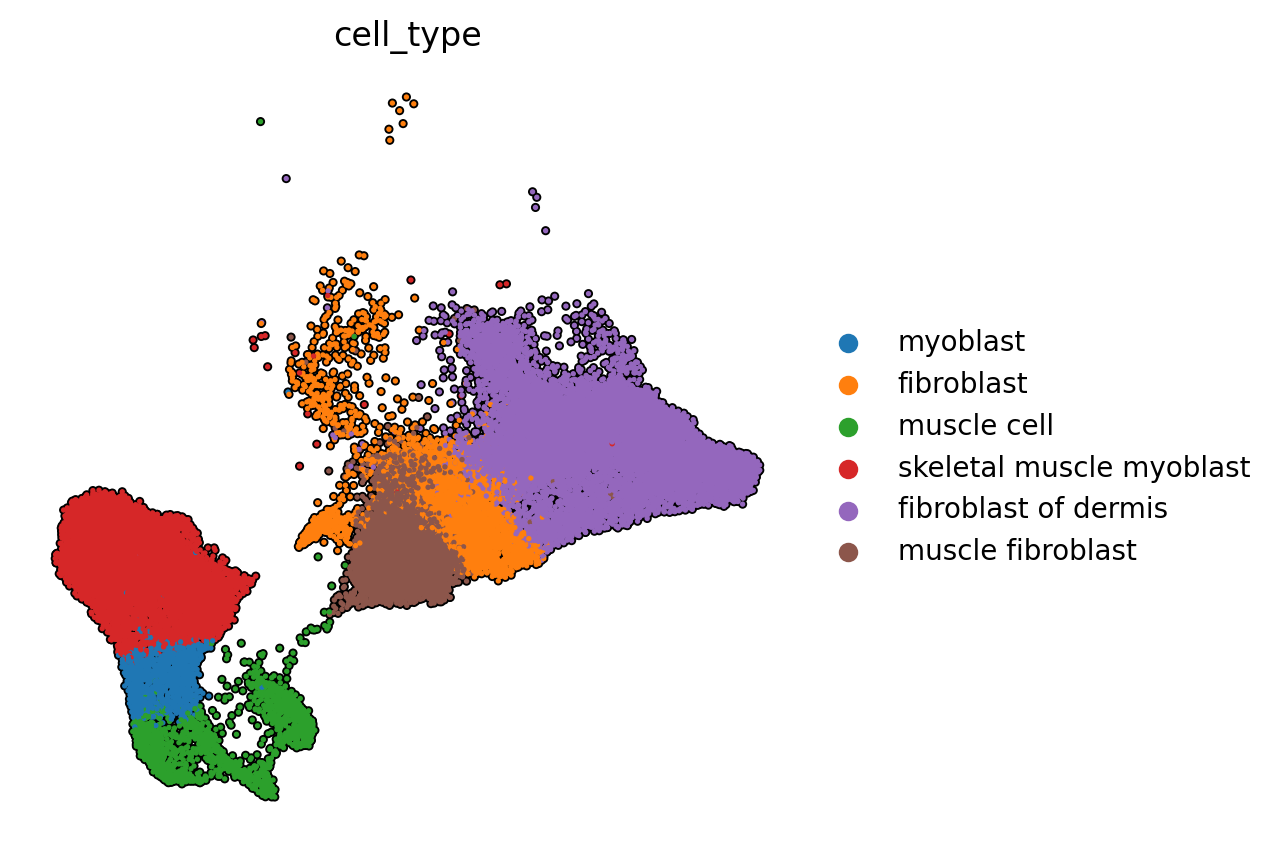

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.umap(
    adata,
    color='cell_type',
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in processed anndata

In [10]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
bdata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
bdata

Memory usage: current 16.88 GB, difference +3.92 GB
CPU times: user 254 ms, sys: 1.07 s, total: 1.33 s
Wall time: 4.22 s


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

#

In [ ]:
# rsc.get.anndata_to_GPU(adata)
# rsc.pp.filter_cells(adata, min_counts=200)
# rsc.pp.filter_genes(adata, min_counts=50)

# adata.layers['counts'] = adata.X.get()

# rsc.pp.normalize_total(adata, target_sum=1e4)
# rsc.pp.log1p(adata)

# adata.layers['log_norm'] = adata.X.get()

# rsc.get.anndata_to_CPU(adata) # move to GPU
# adata

In [ ]:
# adata.raw = adata  # keep full dimension safe
# print(f"Number of genes before HVG selection: {adata.n_vars}")

# rsc.get.anndata_to_GPU(adata)

# rsc.pp.highly_variable_genes(
#     adata, 
#     batch_key="cell_type",
# )

# adata = adata[:, adata.var['highly_variable']].copy()

# print(f"Number of genes after HVG selection: {adata.n_vars}")

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 5, 4
# sc.pl.highly_variable_genes(
#     adata
# )

# adata

In [ ]:
# rsc.get.anndata_to_CPU(adata)

# sc.pp.pca(
#     adata,
# )

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 5, 3
# sc.pl.pca_variance_ratio(
#     adata
# )

# adata

In [ ]:
# # rsc.get.anndata_to_GPU(adata)

# # rsc.pp.neighbors(
# #     adata,
# # )

# # rsc.tl.umap(
# #     adata,
# # )

# # rsc.tl.leiden(
# #     adata,
# #     resolution=0.35,
# # )

# # rsc.get.anndata_to_CPU(adata)

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 10, 10


# sc.pl.umap(
#     adata,
#     color=['cell_type', 'leiden', 'Dataset'],
#     size=15,
#     ncols=1,
#     add_outline=True,
#     outline_color=('k', 'k'),
#     frameon=False,
# )

# Myofiber

In [2]:
%%time
fpath="/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference/refdata-gex-GRCh38-2024-A_genes.csv.gz"
gdf = pd.read_csv(fpath, low_memory=False)
print(f"{gdf.shape=}")

# map from ensmbl IDs to gene names
id2gene = dict(zip(gdf['gene_id'].values, gdf['gene_name'].values))

# map from gene names to ensembl IDs
gene2id = dict(zip(gdf['gene_name'].values, gdf['gene_id'].values))

# label the pt genes
protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['gene_name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(3293161, 27)
N protein coding: protein_coding.shape=(19405,)
CPU times: user 14.9 s, sys: 3.46 s, total: 18.4 s
Wall time: 18.7 s


In [3]:
%%time
# Last run time 2min 5s
# --- paths ---------------------------------------------------------------
datas = {
    'HM05' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098741_HM05.csv.gz',
    'HM08' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098744_HM08.csv.gz',
    'HM10' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098746_HM10.csv.gz',
    'HM13' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098749_HM13.csv.gz',
    'HM21' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098751_HM21.csv.gz',
    'HM22' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098752_HM22.csv.gz',
}
# --- load each dataset in list -------------------------
adatas1 = []
for name, path in datas.items():
    print(f"Working on {name}...")
    a0 = pd.read_csv(path, index_col=0)
    a0 = a0.T
    a = an.AnnData(a0)
    a.obs['dataset'] = name
    adatas1.append(a)
print("Data loaded.")

Working on HM05...
Working on HM08...
Working on HM10...
Working on HM13...
Working on HM21...
Working on HM22...
Data loaded.
CPU times: user 2min 20s, sys: 23 s, total: 2min 43s
Wall time: 2min 44s


AnnData object with n_obs × n_vars = 49645 × 13309
    obs: 'dataset', 'group'
    var: 'gene_id', 'gene_name'

In [16]:
# --- concatenate -------------------------
mdata = an.concat(
    adatas1,
    axis=0,              # stack cells
    merge="unique",      # keep all obs columns; keep all genes, fill missing values with NaN
    label="dataset",     # new obs column with dataset name
    keys=list(datas),    # used by label and index_unique
    index_unique="-"     # make cell barcodes unique (adds "-dataset" suffix)
)

mdata.var['gene_id'] = mdata.var.index.map(gene2id) # add gene IDs
mask = mdata.var['gene_id'].notna() # remove NaN gene IDs
mdata = mdata[:, mask].copy()
mdata.var['gene_name'] = mdata.var_names # save gene names as column
# mdata.var_names = mdata.var['gene_id'].values # set gene ID as index
mdata.obs['group'] = 'myofiber_data' # add group identifier

# save counts 
mdata.layers['raw_counts'] = mdata.X.copy()

print(mdata)
mdata.var.head()

AnnData object with n_obs × n_vars = 49645 × 13309
    obs: 'dataset', 'group'
    var: 'gene_id', 'gene_name'
    layers: 'raw_counts'


,gene_id,gene_name
LINC00115,ENSG00000225880,LINC00115
NOC2L,ENSG00000188976,NOC2L
KLHL17,ENSG00000187961,KLHL17
PERM1,ENSG00000187642,PERM1
HES4,ENSG00000188290,HES4


In [17]:
mdata.var['protein_coding'] = mdata.var['gene_name'].isin(protein_coding)
print(mdata.var['protein_coding'].value_counts().to_string())

protein_coding
True     12750
False      559


In [18]:
%%time
rsc.get.anndata_to_CPU(mdata)
X = mdata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    mdata.X = X
else:
    # dense array
    mdata.X = np.nan_to_num(X, nan=0)

mdata.X = mdata.X.astype(float)
print(f"{mdata.X.shape=}")
print(f"{type(mdata.X)=}")
print(f"{mdata.X.dtype=}")

mdata

mdata.X.shape=(49645, 13309)
type(mdata.X)=<class 'numpy.ndarray'>
mdata.X.dtype=dtype('float64')
CPU times: user 3.35 s, sys: 6.83 s, total: 10.2 s
Wall time: 10.3 s


AnnData object with n_obs × n_vars = 49645 × 13309
    obs: 'dataset', 'group'
    var: 'gene_id', 'gene_name', 'protein_coding'
    layers: 'raw_counts'

In [19]:
%%time
print("Annotating mitochondrial, ribosomal, and hemoglobin genes...")
mdata.var["mt"] = mdata.var_names.str.startswith("MT-")
mdata.var["ribo"] = mdata.var_names.str.startswith(("RPS", "RPL"))
mdata.var["hb"] = mdata.var_names.str.contains("^HB[^(P)]")

print("Moving AnnData to CPU for QC metric calculation...")
rsc.get.anndata_to_CPU(mdata)

print("Calculating QC metrics (log1p transformed)...")
sc.pp.calculate_qc_metrics(
    mdata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

mdata.var.head()

Annotating mitochondrial, ribosomal, and hemoglobin genes...
Moving AnnData to CPU for QC metric calculation...
Calculating QC metrics (log1p transformed)...
CPU times: user 13.8 s, sys: 8 s, total: 21.8 s
Wall time: 22 s


,gene_id,gene_name,protein_coding,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
LINC00115,ENSG00000225880,LINC00115,False,False,False,False,1792,0.037506,0.036820,96.390372,1862.0,7.529943
NOC2L,ENSG00000188976,NOC2L,True,False,False,False,5232,0.115621,0.109411,89.461174,5740.0,8.655389
KLHL17,ENSG00000187961,KLHL17,True,False,False,False,628,0.012912,0.012829,98.735019,641.0,6.464588
PERM1,ENSG00000187642,PERM1,True,False,False,False,12132,0.326961,0.282892,75.562494,16232.0,9.694801
HES4,ENSG00000188290,HES4,True,False,False,False,1242,0.029892,0.029454,97.498237,1484.0,7.303170


In [20]:
%%time

# mdata.X = mdata.layers['raw_counts'].copy()

print("Transferring AnnData back to GPU...")
rsc.get.anndata_to_GPU(mdata)

print("Filtering cells with fewer than 500 counts...")
rsc.pp.filter_cells(mdata, min_counts=500)

print("Filtering genes with fewer than 10 total counts...")
rsc.pp.filter_genes(mdata, min_counts=10)

print("Filtering genes with zero counts across all cells...")
mdata = mdata[:, (mdata.var['total_counts'] > 0)].copy()

min_n_genes = 1000
print(f"Subsetting cells with more than {min_n_genes} genes detected...")
mdata = mdata[mdata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

print("Normalizing total counts to 1e4 per cell...")
rsc.pp.normalize_total(mdata, target_sum=1e4)

print("Applying log1p transformation...")
rsc.pp.log1p(mdata)

# print("Computing highly variable genes...")
# rsc.pp.highly_variable_genes(mdata)

print("Storing log-normalized data in .layers['log_norm']...")
mdata.layers['log_norm'] = mdata.X.copy()

print("Preprocessing complete.")
mdata

Transferring AnnData back to GPU...
Filtering cells with fewer than 500 counts...
filtered out 1481 cells that have less than 500 counts
Filtering genes with fewer than 10 total counts...
Filtering genes with zero counts across all cells...
Subsetting cells with more than 1000 genes detected...
Normalizing total counts to 1e4 per cell...
Applying log1p transformation...
Storing log-normalized data in .layers['log_norm']...
Preprocessing complete.
CPU times: user 42.1 s, sys: 25.4 s, total: 1min 7s
Wall time: 1min 16s


AnnData object with n_obs × n_vars = 18139 × 13309
    obs: 'dataset', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes'
    var: 'gene_id', 'gene_name', 'protein_coding', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'raw_counts', 'log_norm'

In [21]:
mdata.var['filter_pass'] = True # set the gene filter

# pt genes only
mdata.var['filter_pass'] = np.where(~mdata.var.index.isin(protein_coding), False, mdata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
mdata.var['filter_pass'] = np.where(mdata.var.index.str.startswith('MT'), False, mdata.var['filter_pass'])
mdata.var['filter_pass'] = np.where(mdata.var.index.str.startswith('RP'), False, mdata.var['filter_pass'])

print(mdata.var['filter_pass'].value_counts().to_string())

filter_pass
True     12547
False      762


INFO: GPU available: True (cuda), used: True
2025-10-17 17:35:14 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2025-10-17 17:35:14 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-10-17 17:35:14 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2025-10-17 17:35:14 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: SLURM auto-requeueing enabled. Setting signal handlers.
2025-10-17 17:35:14 | [INFO] SLURM auto-requeueing enabled. Setting signal handlers.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 662.245. Signaling Trainer to stop.


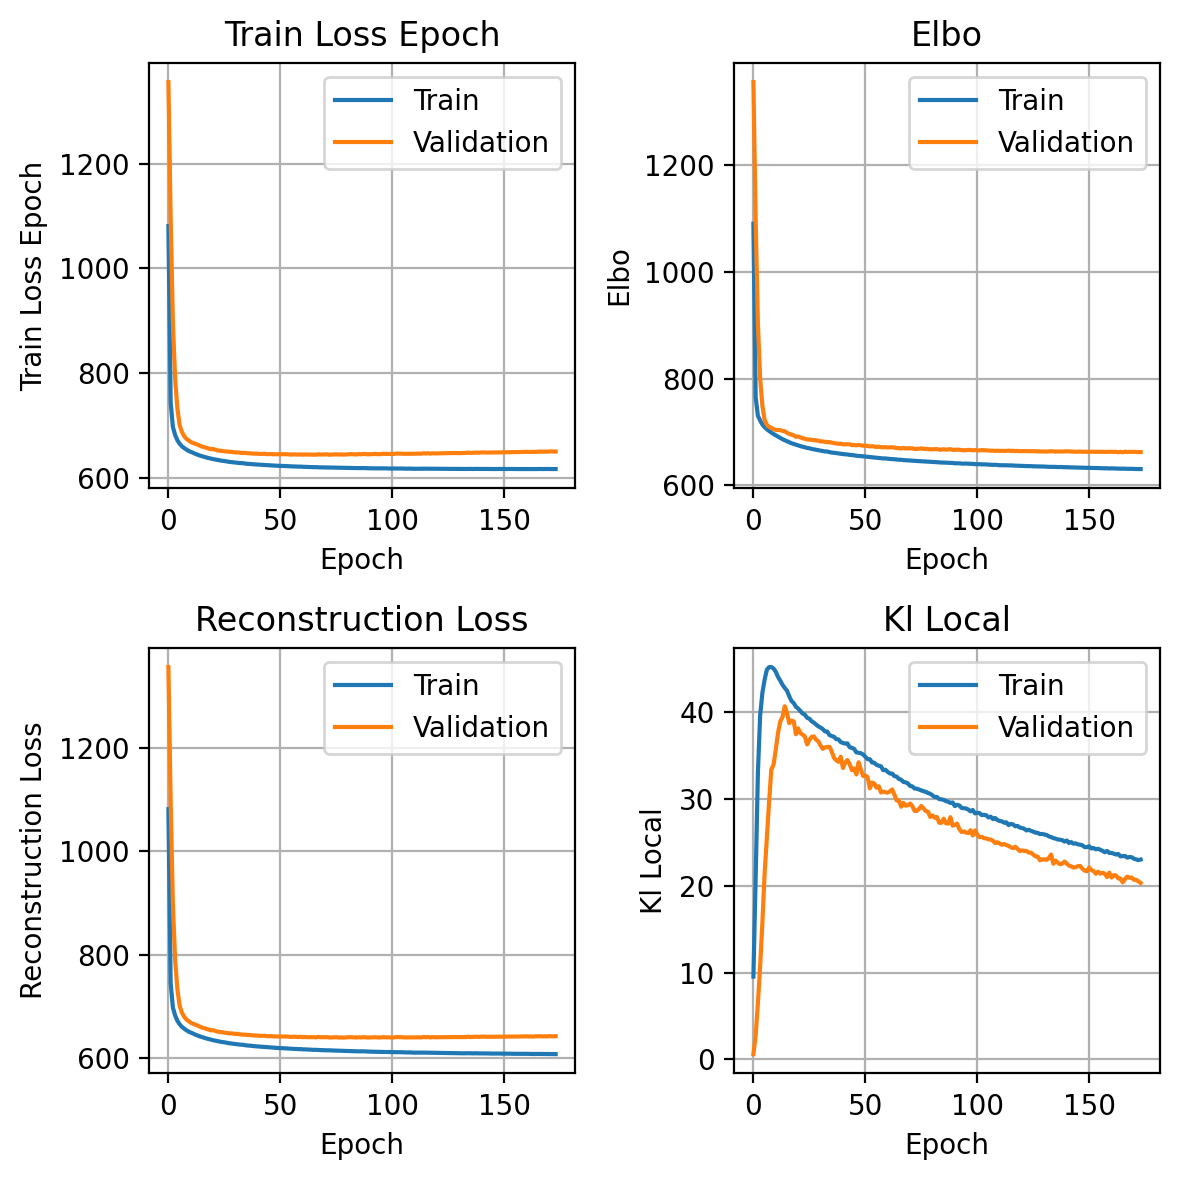

CPU times: user 2min 7s, sys: 12.9 s, total: 2min 19s
Wall time: 2min 24s


In [23]:
%%time
batch_key = "dataset"

rsc.get.anndata_to_CPU(mdata)
bdata = mdata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy() # retains protein-coding, removes mito and ribo genes
bdata.X = bdata.layers['raw_counts'].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=3000,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    # continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=200, # 200
    accelerator='gpu',
    early_stopping_patience=10, # 5
    early_stopping=True,
    batch_size=500,
    plan_kwargs={"lr": 1e-3},
)

# clear cache once finished
torch.cuda.empty_cache()     

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

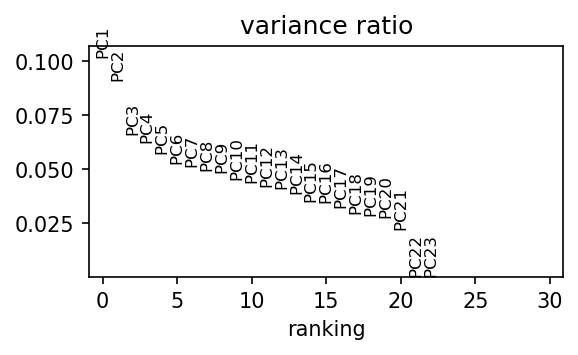

CPU times: user 560 ms, sys: 162 ms, total: 721 ms
Wall time: 863 ms


In [24]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=mdata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

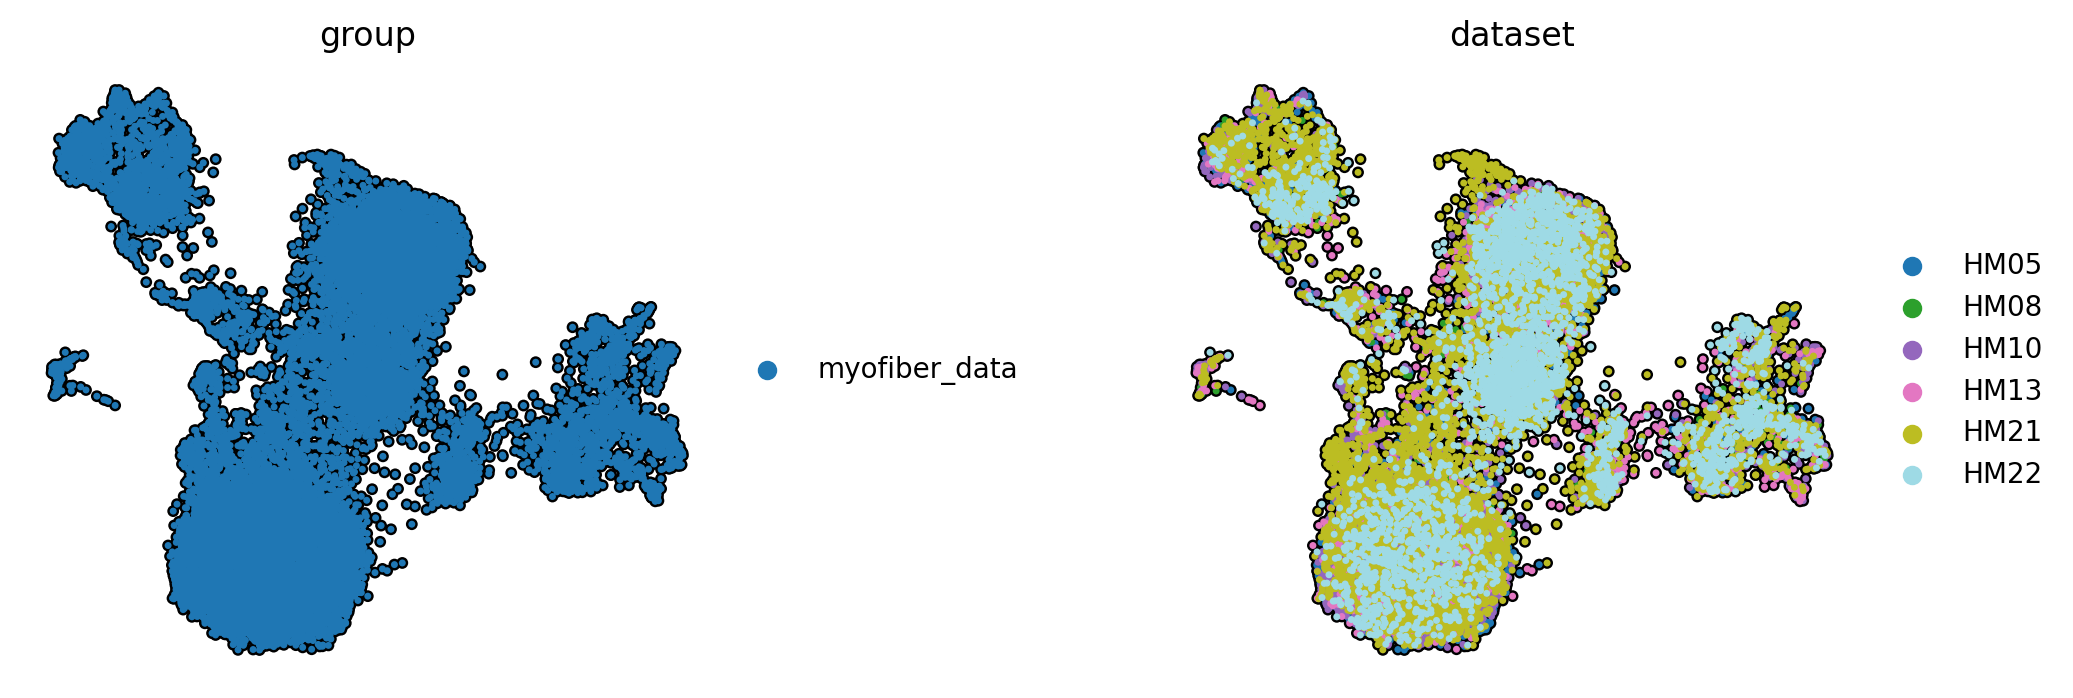

CPU times: user 1.31 s, sys: 28.4 ms, total: 1.34 s
Wall time: 1.37 s


In [27]:
%%time
n_neighbors = 15 # 100
n_pcs = 25
min_dist = 0.25
resolution = 0.75 

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

rsc.tl.umap(embed, min_dist=min_dist)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed,
    color=['group', 'dataset'],#, 'cell_type', 'celltype'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

2025-10-17 18:02:05 | [INFO] init
... storing 'cluster' as categorical



cluster
A7     7105
A1     5551
A5     1702
A8     1436
A4      746
A6      444
A3      433
A2      346
A10     213
A9      163



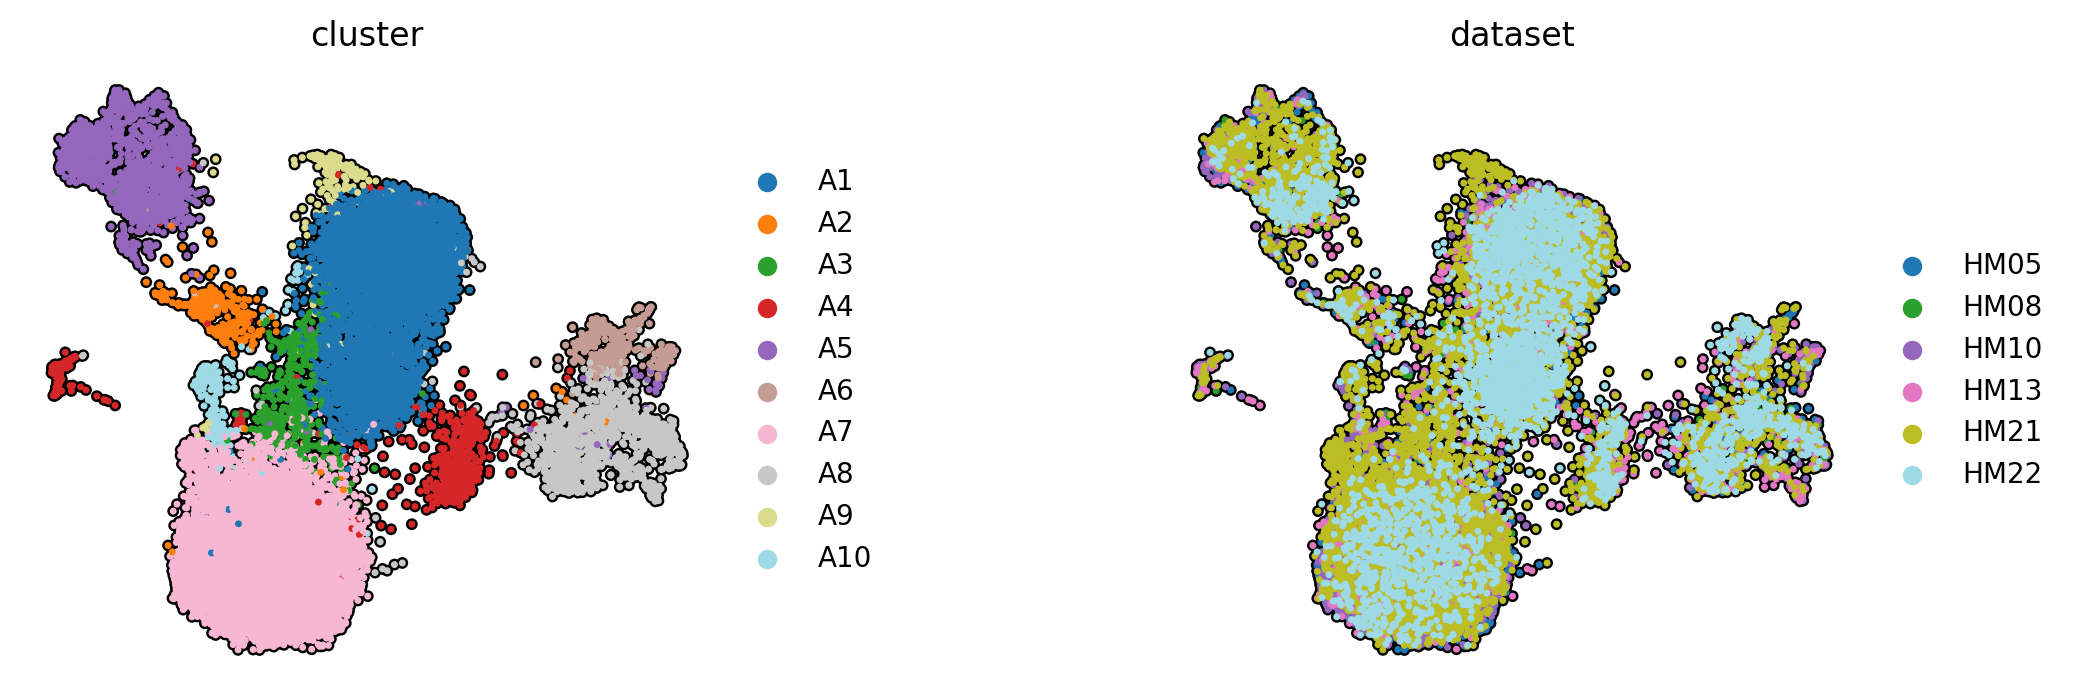

In [28]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

rsc.tl.leiden(embed, resolution=0.75)

embed.obs['cluster'] = embed.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
embed.obs['cluster'] = embed.obs['cluster'].astype('str')

print()
print(embed.obs['cluster'].value_counts().to_string())
print()

sc.pl.umap(
    embed,
    color=['cluster', 'dataset'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [ ]:
if isinstance(mdata.layers['log_norm'], cp.ndarray):
    mdata.layers['log_norm'] = cp.asnumpy(mdata.layers['log_norm'])
print(type(mdata.layers['log_norm'])) # should be <class 'numpy.ndarray'>

immune cells


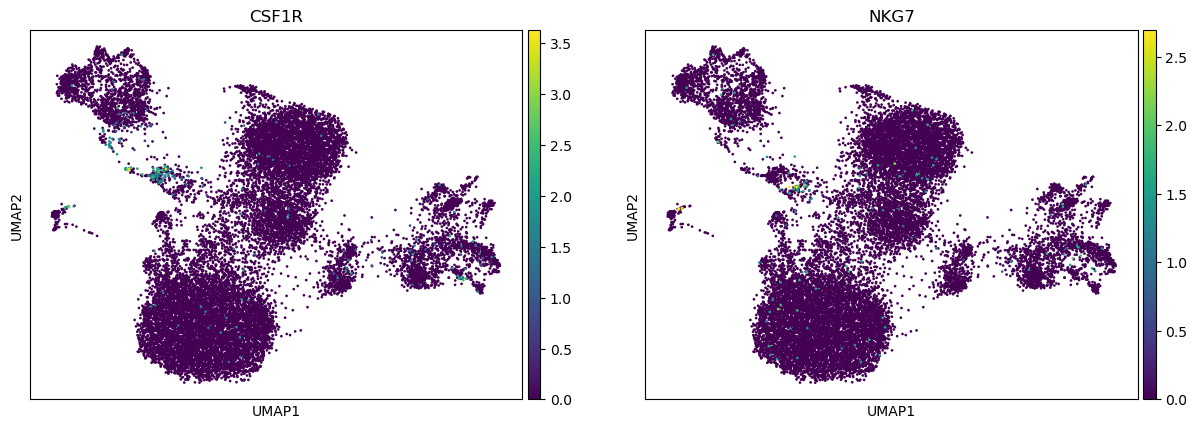

satellite cells


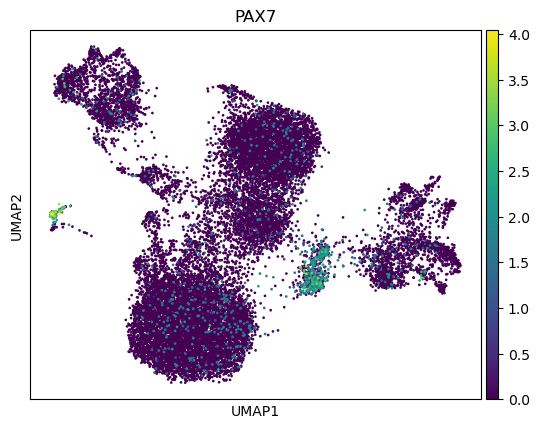

FAP cells


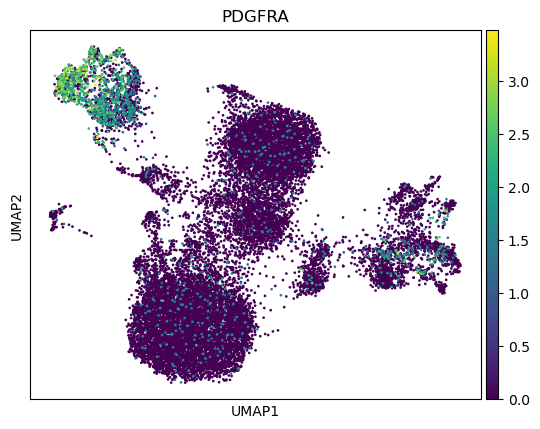

EC cells


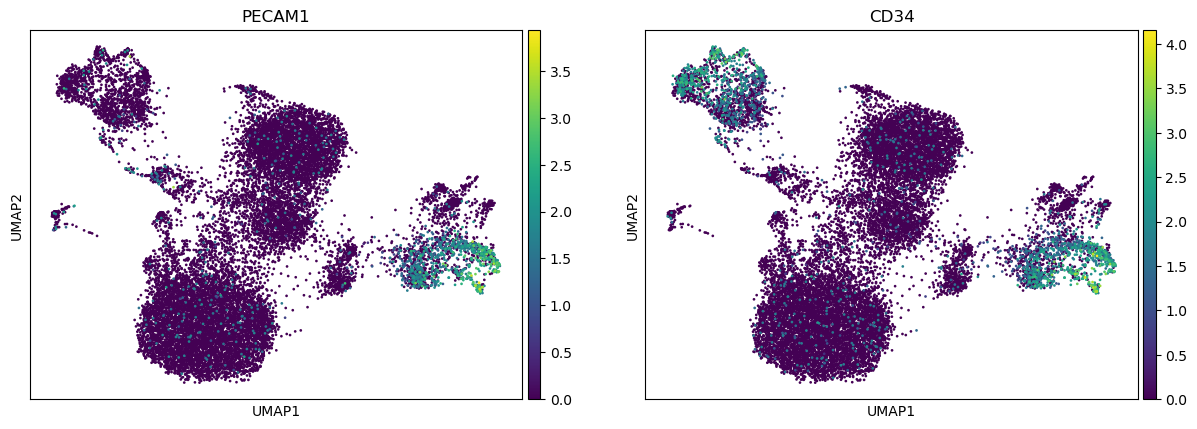

slow_SKM cells


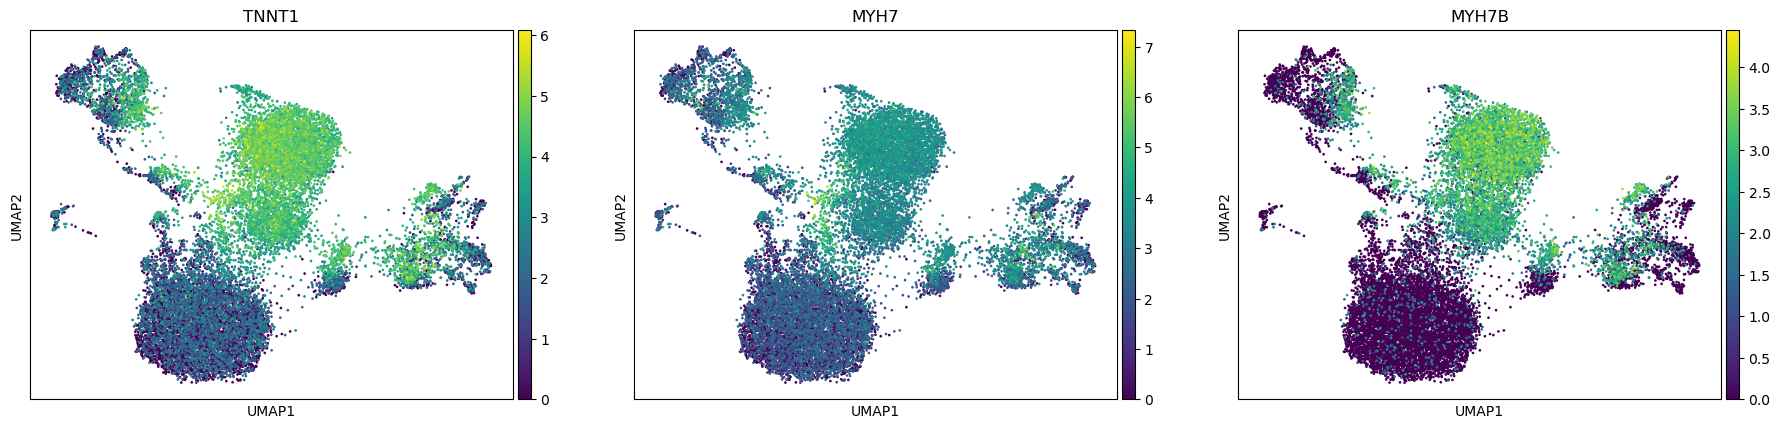

fast_SKM cells


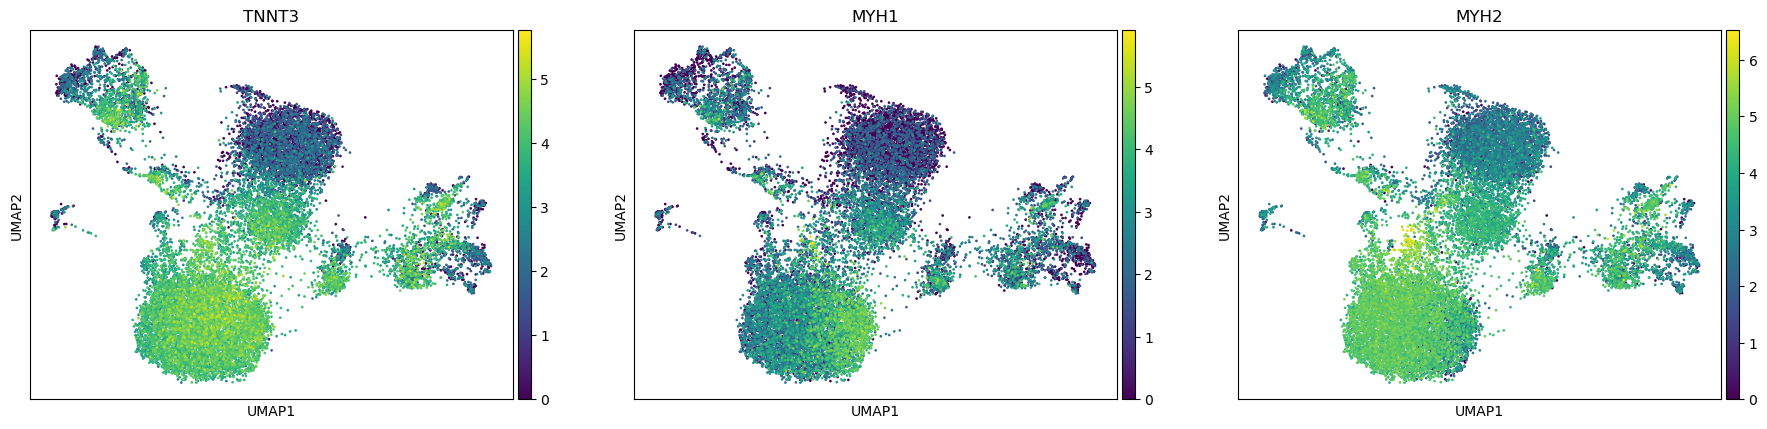

SM cells


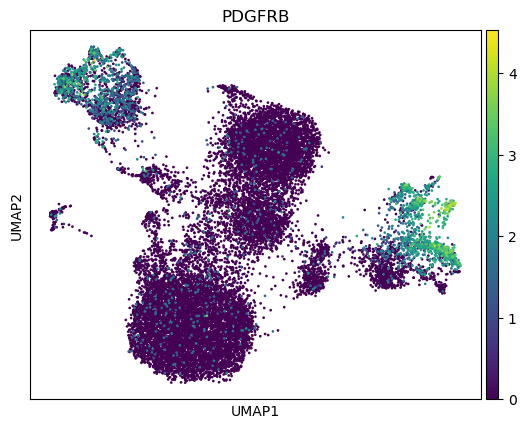

In [46]:
mdata.obsm['X_umap'] = mdata.obsm['X_umap'].copy()

# markers from the original paper
cell_markers = {
    'immune': ['CSF1R', 'NKG7', 'CD3E'],
    'satellite': ['PAX7'],
    'FAP': ['PDGFRA'],
    'EC': ['PECAM1', 'CD34'],
    'slow_SKM': ['TNNT1', 'MYH7', 'MYH7B'],
    'fast_SKM': ['TNNT3', 'MYH1', 'MYH2'],
    'SM': ['PDGFRB'],
}

plt.rcdefaults()
for cell, genes in cell_markers.items():
    # Make sure genes are present in our dataset
    genes_to_plot = [gene for gene in genes if gene in mdata.var_names]

    print(f"{cell} cells")

    sc.pl.umap(
        mdata,
        color=genes_to_plot,
        ncols=3,
        size=15,
        layer='log_norm',
    )

#

In [10]:
path = "/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_counts.csv.gz"

df = pd.read_csv(path)
print(df.shape)
df.head()

(36694, 77)


,Symbol,X_10,X_11,X_13,X_14,X_15,X_16,X_17,X_18,X_19,...,X_75,X_76,X_77,X_78,X_79,X_7,X_80,X_81,X_8,X_9
0,TSPAN6,6,8,10,6,4,2,5,3,5,...,5,7,6,9,3,3,7,5,4,1
1,TNMD,0,1,0,0,1,1,0,0,0,...,0,2,0,0,0,0,0,0,0,0
2,DPM1,20,35,14,22,17,9,30,22,22,...,34,22,35,20,23,19,40,12,6,34
3,SCYL3,18,10,6,18,9,9,11,18,8,...,11,13,11,12,12,9,5,8,5,10
4,C1orf112,1,2,1,1,2,0,0,1,0,...,2,0,0,1,1,0,0,1,2,0


In [15]:
print(df.columns)

Index(['Symbol', 'X_10', 'X_11', 'X_13', 'X_14', 'X_15', 'X_16', 'X_17',
       'X_18', 'X_19', 'X_1', 'X_20', 'X_21', 'X_22', 'X_23', 'X_24', 'X_25',
       'X_26', 'X_27', 'X_29', 'X_2', 'X_30', 'X_32', 'X_33', 'X_34', 'X_35',
       'X_37', 'X_38', 'X_39', 'X_3', 'X_40', 'X_41', 'X_42', 'X_43', 'X_44',
       'X_45', 'X_46', 'X_47', 'X_48', 'X_49', 'X_4', 'X_50', 'X_51', 'X_52',
       'X_53', 'X_54', 'X_55', 'X_56', 'X_57', 'X_58', 'X_59', 'X_5', 'X_60',
       'X_61', 'X_62', 'X_63', 'X_64', 'X_65', 'X_66', 'X_67', 'X_68', 'X_6',
       'X_70', 'X_71', 'X_72', 'X_73', 'X_74', 'X_75', 'X_76', 'X_77', 'X_78',
       'X_79', 'X_7', 'X_80', 'X_81', 'X_8', 'X_9'],
      dtype='object')


In [17]:
path = "/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098741_HM05.csv.gz"

tmp = pd.read_csv(path)
tmp.head()

,Unnamed: 0,AAACCTGAGTACGCCC,AAACCTGAGTGGTCCC,AAACCTGGTAAGAGAG,AAACCTGGTAAGTGGC,AAACCTGGTACCAGTT,AAACCTGGTAGTAGTA,AAACCTGGTCCTAGCG,AAACCTGGTCGCGGTT,AAACCTGGTGAAAGAG,...,TTTGGTTTCCGGGTGT,TTTGGTTTCTACTCAT,TTTGTCAAGCACCGTC,TTTGTCAAGCGATTCT,TTTGTCAAGCTGATAA,TTTGTCAAGGCTAGAC,TTTGTCAGTATTAGCC,TTTGTCAGTTGTCTTT,TTTGTCATCATGTGGT,TTTGTCATCGCAAACT
0,AL627309.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AL669831.5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,FAM87B,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LINC00115,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,FAM41C,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
